<a href="https://colab.research.google.com/github/aniruddhagalgali/bprim_ai/blob/main/20260920_20260926_The_Right_to_Choose_%E2%80%94_Options_%26_Black_Scholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Right to Choose — Options & Black-Scholes

*   An option is the RIGHT, not obligation to trade at a a fixed price
*   Never forced into a bad deal so loss stops at what you paid
*   On winning side, the gain keeps growing



Terminology


| Word     | Plain Meaning | Example of Flat  | Example of Reliance share |
| -------- | -------- | -------- | -------- |
| Call     | The right to BUY at a fixed price  | Booking amount   | The right to BUY Reliance shares |
| Put    | The right to SELL at a fixed price   | A buy-back guarantee from builded   | The right SELL Reliance shares |
| Strike K | The fixed price in the contract | &#8377;80 Lakh | &#8377; 1560 per share |
| Expiry T | The deadline | 2 months | 1 month |
| Premium | What the buyer pays up front for the right thing | &#8377;.1 Lakh | About &#8377;41 |
| Underlying S | The thing it is written on and its price now | The flat | Relance price as of today &#8377;1563 |




Options are not just for traders

| Who | What worries them | The right they buy | Call or put?|
| -------- | -------- | -------- | -------- |
| An airline | Jet fuel gets expensive | The right to BUY fuel ( or crude oil ) at a fixed price | Call |
| An IT exporter paid in dollars | The rupee strengthens, so each dollar brings fewer rupees | The right to SELL dollars at a fixed rupee rate | Put |
| A soybean farmer | The price crashes at harvest | The right to SELL the crop at a fixed price : A floor much like MSP | Put |
| A mutual fund manager | The market falls after the budget or an election | The right to SELL the Nifty at a fixed level | Put |


What the option pays on expiry day

Call payoff = max ( Sₜ - K, 0)

Put payoff = max ( K - Sₜ, 0)

Reliance ends at &#8377;1700 &rarr; call = max (140,0) = &#8377;140,   put = max (-140, 0) = &#8377;0

Reliance ends at &#8377;1450 &rarr; call = max (-110,0) = &#8377;0,   put = max (110, 0) = &#8377;110

Profit = payoff - premium &rarr; Call cost = &#8377;41, so at &#8377;1700 the buyer is &#8377;99 ahead

Who pays whon

*   Every option has two sides
*   The buyer pays the premium and gets a right
*   The writer (seller) collects the premium and takes on a duty
*   The buyer's worst case is known on  day one. The writer's is not.



In, at or out of the money

| Where Reliance is (strike &#8377;1560 | Name | The call (right to buy) | The put (right to sell) |
| -------- | -------- | -------- | -------- |
| Above the strike say 1650 ||||

# Strategies

*   Buy and put
*   Rent a call
*   Straddle - A bet of a big move, direction unknown

$price today = e^{-rT} x average of max (S_T - K,0)

$e^{i\pi} + 1

# Black Scholes

price today
strike
time left
interest rate
volatility

are inputs to black scholes and ouput is
call price
put price

| Who | What worries them | The right they buy | Call or put?|

| Greek | Measures | Think of it as |
| -------- | -------- | -------- |
| Delta | change in the option price when the stock moves re1  | speed: how closely the option follows the stock |
| Gamma  | change in Delta when the stock moves &#8377;1  | acceleration: how fast  the speed changes |
| Theta  | change in Delta when the stock moves &#8377;1  | acceleration: how fast  the speed changes |
| Vega  | change in Delta when the stock moves &#8377;1  | acceleration: how fast  the speed changes |

Where does Black Scholes fail

*   Volatily changes
*   Fat tails
*   Price jump on news
*   Spreads brokerage

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [9]:
# Reliance example

S0 = 1563.17 # Current Reliance Price
K = 1560 # Strike Price
T = 1/12 # 1 month
r = 0.06 # 6% interest rate
sigma = 0.20 # 20% volality

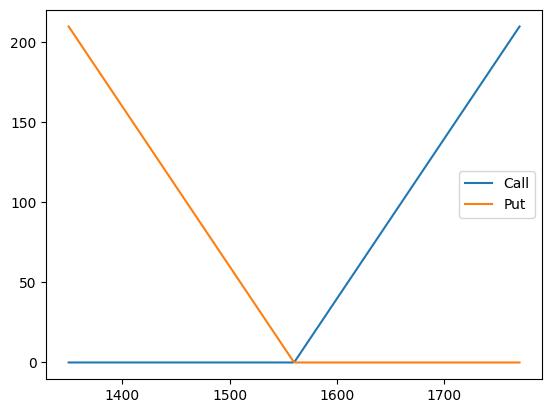

In [19]:
S  = np.linspace(1350,1770,200)
call_payoff = np.maximum(S-K,0)
put_payoff = np.maximum(K-S,0)
plt.plot(S,call_payoff, label="Call payoff")
plt.plot(S,put_payoff, label="Put payoff")
plt.legend(['Call','Put'])
plt.show()

In [27]:
def black_scholes(S,K,T,r,sigma):
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
  d2 = d1 - sigma*np.sqrt(T)

  call = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
  put = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

  return call,put

call, put = black_scholes(S0,K,T,r,sigma)
print(round(call,2))
print(round(put,2))

41.61
30.66


In [28]:
for vol in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
  call, put = black_scholes(S0,K,T,r,vol)
  print(round(call,2),round(put,2))

23.94 12.99
41.61 30.66
59.45 48.5
77.32 66.37
95.2 84.25
113.06 102.11
130.91 119.96
148.74 137.79
166.53 155.58
184.3 173.35
